# K* (K-Star) Means Clustering on Preprocessed Telco Dataset

This notebook implements K* (K-star) means clustering, an algorithm that automatically determines the optimal number of clusters using Minimum Description Length (MDL) principle.

**Key Features:**
- Automatically finds optimal K (no need to specify number of clusters)
- Uses MDL cost function for model selection
- Performs adaptive splitting and merging of clusters

In [361]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import kmeans_plusplus
from sklearn.metrics import (
    silhouette_score, 
    davies_bouldin_score, 
    calinski_harabasz_score
)
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## K* Means Implementation

Implementation of K* Means algorithm with MDL-based automatic cluster number selection.

In [362]:
class KStarMeans:
    """
    K*-means clustering algorithm with automatic cluster number selection
    using Minimum Description Length (MDL) principle.
    """
    
    def __init__(self, patience=5, omega1=1.0, omega2=1.0, random_state=42):
        """
        Initialize K*-means clustering.
        
        Parameters:
        -----------
        patience : int
            Number of iterations without improvement before stopping
        omega1 : float
            Multiplier for model cost to control cluster count (default=1.0)
            Higher values (2-15) penalize more clusters, leading to fewer clusters
            Recommended: 5-15 for business contexts requiring 3-7 clusters
        omega2 : float
            Multiplier for index cost to control cluster assignment cost (default=1.0)
            Higher values penalize more clusters by increasing assignment cost
            Recommended: 1-5 for fine-tuning cluster count
        random_state : int
            Random seed for reproducibility
        """
        self.patience = patience
        self.omega1 = omega1
        self.omega2 = omega2
        self.random_state = random_state
        self.centroids = None
        self.labels = None
        self.cost_history = []
        
    def _init_subcentroids(self, X):
        """
        Initialize two sub-centroids for a cluster using k-means++.
        
        Parameters:
        -----------
        X : ndarray
            Data points in the cluster
            
        Returns:
        --------
        list : Two initial sub-centroid positions
        """
        if len(X) < 2:
            return [X[0].copy(), X[0].copy()]
        
        # Use k-means++ initialization for better initial positions
        centers, _ = kmeans_plusplus(X, n_clusters=min(2, len(X)), random_state=self.random_state)
        return [centers[0], centers[1] if len(centers) > 1 else centers[0]]
    
    def _mdl_cost(self, X, centroids, clusters):
        """
        Calculate MDL cost: Model Cost + Index Cost + Residual Cost
        
        Parameters:
        -----------
        X : ndarray
            Full dataset
        centroids : list
            List of cluster centroids
        clusters : list
            List of clusters (each cluster is array of point indices)
            
        Returns:
        --------
        float : Total MDL cost
        """
        n, d = X.shape
        k = len(centroids)
        
        if k == 0:
            return np.inf
        
        # Calculate float precision based on minimum distance between values
        X_flat = X.flatten()
        unique_vals = np.unique(X_flat)
        if len(unique_vals) > 1:
            min_dist = np.min(np.diff(np.sort(unique_vals)))
            floatprecision = max(-np.log(min_dist), 1e-10)
        else:
            floatprecision = 1.0
        
        # Model cost: encoding centroids
        floatcost = (np.max(X) - np.min(X)) / floatprecision
        modelcost = k * d * floatcost
        
        # Index cost: encoding cluster assignments
        idxcost = n * np.log(k) if k > 1 else 0
        
        # Residual cost: encoding data given centroids
        squared_distances = 0
        for i, cluster_indices in enumerate(clusters):
            if len(cluster_indices) > 0:
                cluster_points = X[cluster_indices]
                squared_distances += np.sum((cluster_points - centroids[i])**2)
        
        residualcost = (n * d * np.log(2 * np.pi) + squared_distances) / 2
        
        # Apply omega multipliers to model cost and index cost for cluster count control
        total_cost = (self.omega1 * modelcost) + (self.omega2 * idxcost) + residualcost
        return total_cost
    
    def _assign_to_centroids(self, X, centroids):
        """
        Assign each point to nearest centroid.
        
        Parameters:
        -----------
        X : ndarray
            Data points
        centroids : list
            List of centroids
            
        Returns:
        --------
        list : List of clusters (arrays of indices)
        """
        if len(centroids) == 0:
            return []
        
        # Calculate distances to all centroids
        distances = np.array([np.linalg.norm(X - c, axis=1) for c in centroids])
        labels = np.argmin(distances, axis=0)
        
        # Create clusters as lists of indices
        clusters = [np.where(labels == i)[0] for i in range(len(centroids))]
        return clusters
    
    def _kmeans_step(self, X, centroids, clusters, subcentroids, subclusters):
        """
        Perform one k-means iteration: assign points and update centroids.
        
        Parameters:
        -----------
        X : ndarray
            Full dataset
        centroids : list
            Main centroids
        clusters : list
            Main clusters
        subcentroids : list
            Sub-centroids for each main cluster
        subclusters : list
            Sub-clusters for each main cluster
            
        Returns:
        --------
        tuple : Updated (centroids, clusters, subcentroids, subclusters)
        """
        # Assign points to nearest centroid
        clusters = self._assign_to_centroids(X, centroids)
        
        # Update centroids
        new_centroids = []
        new_subcentroids = []
        new_subclusters = []
        
        for i, cluster_indices in enumerate(clusters):
            if len(cluster_indices) > 0:
                cluster_points = X[cluster_indices]
                new_centroid = np.mean(cluster_points, axis=0)
                new_centroids.append(new_centroid)
                
                # Update sub-centroids for this cluster
                if i < len(subcentroids):
                    sub_c1, sub_c2 = subcentroids[i]
                else:
                    sub_c1, sub_c2 = self._init_subcentroids(cluster_points)
                
                # Assign to sub-centroids
                sub_clusters = self._assign_to_centroids(cluster_points, [sub_c1, sub_c2])
                
                # Update sub-centroids
                if len(sub_clusters[0]) > 0:
                    sub_c1 = np.mean(cluster_points[sub_clusters[0]], axis=0)
                if len(sub_clusters[1]) > 0:
                    sub_c2 = np.mean(cluster_points[sub_clusters[1]], axis=0)
                
                new_subcentroids.append([sub_c1, sub_c2])
                new_subclusters.append(sub_clusters)
            else:
                new_centroids.append(centroids[i])
                if i < len(subcentroids):
                    new_subcentroids.append(subcentroids[i])
                    new_subclusters.append(subclusters[i] if i < len(subclusters) else [[], []])
        
        return new_centroids, clusters, new_subcentroids, new_subclusters
    
    def _maybe_split(self, X, centroids, clusters, subcentroids, subclusters):
        """
        Try to split each cluster and keep the best split if it reduces cost.
        
        Parameters:
        -----------
        X : ndarray
            Full dataset
        centroids : list
            Main centroids
        clusters : list
            Main clusters
        subcentroids : list
            Sub-centroids
        subclusters : list
            Sub-clusters
            
        Returns:
        --------
        tuple : (centroids, clusters, subcentroids, subclusters, did_split)
        """
        n = len(X)
        current_k = len(centroids)
        best_costchange = 0
        split_at = -1
        
        for i in range(len(centroids)):
            if i >= len(subclusters) or len(clusters[i]) < 2:
                continue
            
            cluster_points = X[clusters[i]]
            subc1, subc2 = subclusters[i]
            submu1, submu2 = subcentroids[i]
            
            # Calculate cost change if we split this cluster
            cost_after_split = 0
            if len(subc1) > 0:
                cost_after_split += np.sum((cluster_points[subc1] - submu1)**2)
            if len(subc2) > 0:
                cost_after_split += np.sum((cluster_points[subc2] - submu2)**2)
            
            cost_before_split = np.sum((cluster_points - centroids[i])**2)
            
            # Add index cost penalty for having one more cluster (weighted by omega2)
            costchange = cost_after_split - cost_before_split + (self.omega2 * n * np.log((current_k + 1) / current_k))
            
            if costchange < best_costchange:
                best_costchange = costchange
                split_at = i
        
        # Perform split if beneficial
        if best_costchange < 0 and split_at >= 0:
            submu1, submu2 = subcentroids[split_at]
            
            # Split the cluster
            new_centroids = centroids[:split_at] + [submu1, submu2] + centroids[split_at+1:]
            
            # Re-assign all points
            new_clusters = self._assign_to_centroids(X, new_centroids)
            
            # Initialize sub-centroids for new clusters
            new_subcentroids = []
            new_subclusters = []
            for cluster_indices in new_clusters:
                if len(cluster_indices) > 0:
                    cluster_points = X[cluster_indices]
                    subs = self._init_subcentroids(cluster_points)
                    sub_clusters = self._assign_to_centroids(cluster_points, subs)
                    new_subcentroids.append(subs)
                    new_subclusters.append(sub_clusters)
                else:
                    new_subcentroids.append([new_centroids[len(new_subcentroids)], 
                                            new_centroids[len(new_subcentroids)]])
                    new_subclusters.append([[], []])
            
            return new_centroids, new_clusters, new_subcentroids, new_subclusters, True
        
        return centroids, clusters, subcentroids, subclusters, False
    
    def _maybe_merge(self, X, centroids, clusters, subcentroids, subclusters):
        """
        Find closest pair of centroids and merge if it reduces cost.
        
        Parameters:
        -----------
        X : ndarray
            Full dataset
        centroids : list
            Main centroids
        clusters : list
            Main clusters
        subcentroids : list
            Sub-centroids
        subclusters : list
            Sub-clusters
            
        Returns:
        --------
        tuple : (centroids, clusters, subcentroids, subclusters)
        """
        k = len(centroids)
        if k < 2:
            return centroids, clusters, subcentroids, subclusters
        
        n = len(X)
        
        # Find closest pair of centroids
        min_dist = np.inf
        i1, i2 = 0, 1
        for i in range(k):
            for j in range(i+1, k):
                dist = np.linalg.norm(centroids[i] - centroids[j])
                if dist < min_dist:
                    min_dist = dist
                    i1, i2 = i, j
        
        # Calculate cost change if we merge
        Z_indices = np.concatenate([clusters[i1], clusters[i2]])
        if len(Z_indices) == 0:
            return centroids, clusters, subcentroids, subclusters
        
        Z = X[Z_indices]
        m_merged = np.mean(Z, axis=0)
        
        mainQ = np.sum((Z - m_merged)**2)
        subcQ = 0
        if len(clusters[i1]) > 0:
            subcQ += np.sum((X[clusters[i1]] - centroids[i1])**2)
        if len(clusters[i2]) > 0:
            subcQ += np.sum((X[clusters[i2]] - centroids[i2])**2)
        
        # Cost change includes index cost benefit from having one fewer cluster (weighted by omega2)
        costchange = mainQ - subcQ - (self.omega2 * n * np.log(k / (k - 1)))
        
        if costchange < 0:
            # Perform merge
            new_centroids = [c for idx, c in enumerate(centroids) if idx not in [i1, i2]]
            new_centroids.insert(i1, m_merged)
            
            # Re-assign all points
            new_clusters = self._assign_to_centroids(X, new_centroids)
            
            # Initialize sub-centroids for new clusters
            new_subcentroids = []
            new_subclusters = []
            for cluster_indices in new_clusters:
                if len(cluster_indices) > 0:
                    cluster_points = X[cluster_indices]
                    subs = self._init_subcentroids(cluster_points)
                    sub_clusters = self._assign_to_centroids(cluster_points, subs)
                    new_subcentroids.append(subs)
                    new_subclusters.append(sub_clusters)
                else:
                    new_subcentroids.append([new_centroids[len(new_subcentroids)], 
                                            new_centroids[len(new_subcentroids)]])
                    new_subclusters.append([[], []])
            
            return new_centroids, new_clusters, new_subcentroids, new_subclusters
        
        return centroids, clusters, subcentroids, subclusters
    
    def fit(self, X):
        """
        Fit K*-means clustering to data.
        
        Parameters:
        -----------
        X : ndarray
            Data to cluster (n_samples, n_features)
            
        Returns:
        --------
        self
        """
        np.random.seed(self.random_state)
        n, d = X.shape
        
        # Initialize with single cluster
        mu = np.mean(X, axis=0)
        centroids = [mu]
        clusters = [np.arange(n)]
        
        # Initialize sub-centroids
        subcentroids = [self._init_subcentroids(X)]
        subclusters = [self._assign_to_centroids(X, subcentroids[0])]
        
        best_cost = np.inf
        unimproved_count = 0
        iteration = 0
        
        print(f"Starting K*-means with patience={self.patience}, ω1={self.omega1}, ω2={self.omega2}")
        print(f"Initial: K=1")
        
        while True:
            iteration += 1
            
            # K-means step
            centroids, clusters, subcentroids, subclusters = self._kmeans_step(
                X, centroids, clusters, subcentroids, subclusters
            )
            
            # Try to split
            centroids, clusters, subcentroids, subclusters, did_split = self._maybe_split(
                X, centroids, clusters, subcentroids, subclusters
            )
            
            if did_split:
                print(f"  Iteration {iteration}: Split performed, K={len(centroids)}")
            
            # If no split, try to merge
            if not did_split:
                centroids, clusters, subcentroids, subclusters = self._kmeans_step(
                    X, centroids, clusters, subcentroids, subclusters
                )
                
                old_k = len(centroids)
                centroids, clusters, subcentroids, subclusters = self._maybe_merge(
                    X, centroids, clusters, subcentroids, subclusters
                )
                
                if len(centroids) < old_k:
                    print(f"  Iteration {iteration}: Merge performed, K={len(centroids)}")
            
            # Calculate cost
            cost = self._mdl_cost(X, centroids, clusters)
            self.cost_history.append(cost)
            
            if iteration % 5 == 0:
                print(f"  Iteration {iteration}: K={len(centroids)}, Cost={cost:.2f}")
            
            # Check for improvement
            if cost < best_cost:
                best_cost = cost
                unimproved_count = 0
                # Save best configuration
                self.centroids = [c.copy() for c in centroids]
                self.labels = np.argmin(
                    np.array([np.linalg.norm(X - c, axis=1) for c in centroids]), 
                    axis=0
                )
            else:
                unimproved_count += 1
            
            # Check stopping criterion
            if unimproved_count >= self.patience:
                print(f"\nConverged after {iteration} iterations")
                print(f"Final K={len(self.centroids)}, Best Cost={best_cost:.2f}")
                break
        
        return self
    
    def predict(self, X):
        """
        Predict cluster labels for new data.
        
        Parameters:
        -----------
        X : ndarray
            Data to predict (n_samples, n_features)
            
        Returns:
        --------
        ndarray : Cluster labels
        """
        if self.centroids is None:
            raise ValueError("Model not fitted yet. Call fit() first.")
        
        distances = np.array([np.linalg.norm(X - c, axis=1) for c in self.centroids])
        return np.argmin(distances, axis=0)

print("✓ K*-means algorithm implemented successfully")

✓ K*-means algorithm implemented successfully


## Load Preprocessed Dataset

In [363]:
# Load preprocessed dataset
input_file = r"C:\Users\weezh\OneDrive\Desktop\pyhercules\dataset\3rd exploration mdl implimentation\Telco_customer_churn_preprocessed.csv"
print("Loading preprocessed dataset...")
df = pd.read_csv(input_file)

# Convert to numpy array for clustering
X = df.values

print(f"Dataset shape: {X.shape}")
print(f"Number of samples: {X.shape[0]:,}")
print(f"Number of features: {X.shape[1]}")
print(f"Data type: {X.dtype}")
print(f"\n✓ Dataset loaded successfully")

Loading preprocessed dataset...
Dataset shape: (7043, 72)
Number of samples: 7,043
Number of features: 72
Data type: float64

✓ Dataset loaded successfully


## Perform K* Means Clustering with Omega Multipliers

The algorithm will automatically determine the optimal number of clusters.

**Omega Parameters Guidance:**

**ω1 (Model Cost Multiplier):**
- Controls the penalty for model complexity (storing centroids)
- `ω1 = 1.0`: Standard penalty
- `ω1 = 5-15`: Strong penalty → Fewer clusters (recommended for business)
- Higher ω1 → Fewer clusters

**ω2 (Index Cost Multiplier):**
- Controls the penalty for cluster assignments
- `ω2 = 1.0`: Standard penalty (recommended starting point)
- `ω2 = 2-5`: Additional penalty → Fewer clusters
- Higher ω2 → Fewer clusters

**Combined Effect:**
- Both parameters work together to control cluster count
- Start with ω1=10, ω2=1 for business contexts (3-7 clusters)
- Increase ω1 for stronger model simplification
- Increase ω2 for additional assignment cost penalty

In [364]:
# Initialize and fit K* Means with omega multipliers
print("Initializing K* Means clustering with omega multipliers...")
print("This may take a few minutes as the algorithm automatically finds optimal K...\n")

# Adjust omega1 and omega2 to control number of clusters
# omega1: Model cost multiplier (recommended: 5-15 for business contexts)
# omega2: Index cost multiplier (recommended: 1-5 for fine-tuning)
omega1_value = 1  # Increase this to penalize more clusters (model complexity)
omega2_value = 4   # Increase this to penalize cluster assignments

kstar = KStarMeans(patience=5, omega1=omega1_value, omega2=omega2_value)
kstar.fit(X)

# Get results
optimal_k = len(kstar.centroids)
labels = kstar.labels

print("="*60)
print("K* MEANS CLUSTERING RESULTS:")
print("="*60)
print(f"Omega1 multiplier (model): {omega1_value}")
print(f"Omega2 multiplier (index): {omega2_value}")
print(f"Automatically determined K: {optimal_k}")
print(f"Total samples: {len(labels):,}")
print("="*60)

# Cluster size distribution
unique, counts = np.unique(labels, return_counts=True)
print("\nCluster Size Distribution:")
percentages = []
for cluster_id, count in zip(unique, counts):
    percentage = (count / len(labels)) * 100
    percentages.append(percentage)
    print(f"  Cluster {cluster_id}: {count:,} samples ({percentage:.1f}%)")

# Show smallest and largest cluster percentages
print(f"\n📊 Cluster Size Analysis:")
print(f"  Smallest cluster: {min(percentages):.2f}% of data")
print(f"  Largest cluster:  {max(percentages):.2f}% of data")
print(f"  Average cluster size: {np.mean(percentages):.2f}%")

Initializing K* Means clustering with omega multipliers...
This may take a few minutes as the algorithm automatically finds optimal K...

Starting K*-means with patience=5, ω1=1, ω2=4
Initial: K=1
  Iteration 1: Split performed, K=2


  Iteration 2: Split performed, K=3
  Iteration 3: Split performed, K=4
  Iteration 5: Split performed, K=5
  Iteration 5: K=5, Cost=693074.21
  Iteration 7: Split performed, K=6
  Iteration 8: Split performed, K=7
  Iteration 9: Split performed, K=8
  Iteration 10: K=8, Cost=691433.47
  Iteration 11: Split performed, K=9
  Iteration 13: Split performed, K=10
  Iteration 14: Split performed, K=11
  Iteration 15: Split performed, K=12
  Iteration 15: K=12, Cost=692911.40

Converged after 15 iterations
Final K=8, Best Cost=691433.47
K* MEANS CLUSTERING RESULTS:
Omega1 multiplier (model): 1
Omega2 multiplier (index): 4
Automatically determined K: 8
Total samples: 7,043

Cluster Size Distribution:
  Cluster 0: 683 samples (9.7%)
  Cluster 1: 842 samples (12.0%)
  Cluster 2: 44 samples (0.6%)
  Cluster 3: 1,059 samples (15.0%)
  Cluster 4: 1,443 samples (20.5%)
  Cluster 5: 1,660 samples (23.6%)
  Cluster 6: 634 samples (9.0%)
  Cluster 7: 678 samples (9.6%)

📊 Cluster Size Analysis:
  Smal

## Evaluate Clustering Quality

Calculate standard clustering metrics to assess the quality of the results.

In [365]:
# Calculate clustering metrics
print("Calculating clustering metrics...")

if optimal_k > 1:
    silhouette = silhouette_score(X, labels)
    davies_bouldin = davies_bouldin_score(X, labels)
    calinski_harabasz = calinski_harabasz_score(X, labels)
    
    print("\n" + "="*60)
    print("CLUSTERING QUALITY METRICS:")
    print("="*60)
    print(f"Silhouette Score:        {silhouette:.4f} (range: [-1, 1], higher is better)")
    print(f"Davies-Bouldin Index:    {davies_bouldin:.4f} (lower is better)")
    print(f"Calinski-Harabasz Score: {calinski_harabasz:.2f} (higher is better)")
    print("="*60)
    
    # Calculate inertia manually
    inertia = 0
    for i in range(optimal_k):
        cluster_points = X[labels == i]
        if len(cluster_points) > 0:
            inertia += np.sum((cluster_points - kstar.centroids[i])**2)
    print(f"\nWithin-Cluster Sum of Squares (Inertia): {inertia:.2f}")
else:
    print("\n⚠ Only one cluster found - cannot calculate comparison metrics")

Calculating clustering metrics...

CLUSTERING QUALITY METRICS:
Silhouette Score:        0.0829 (range: [-1, 1], higher is better)
Davies-Bouldin Index:    2.7012 (lower is better)
Calinski-Harabasz Score: 536.37 (higher is better)

Within-Cluster Sum of Squares (Inertia): 330871.92


## Visualize Clusters using PCA

Applying PCA for 2D visualization...
Explained variance ratio: [0.16859599 0.10436399]
Total variance explained: 27.30%


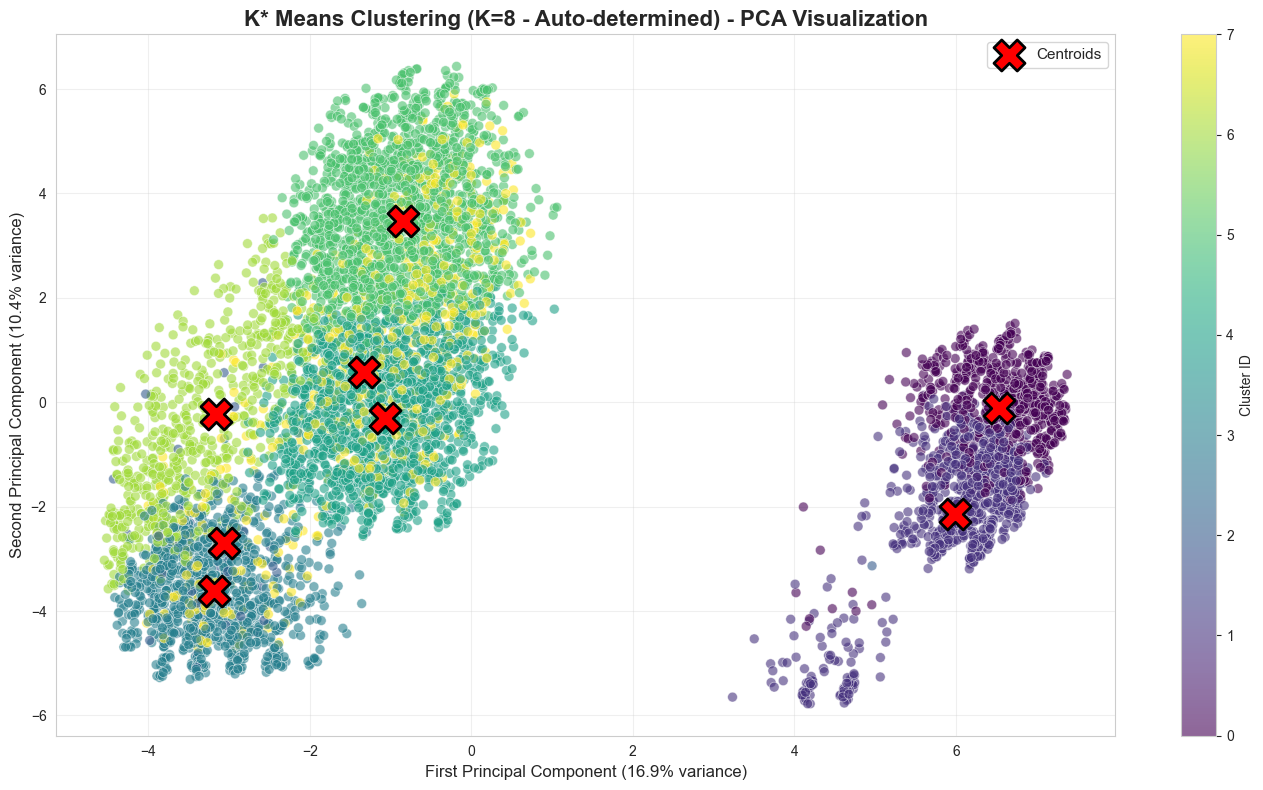

In [366]:
# Apply PCA for 2D visualization
print("Applying PCA for 2D visualization...")
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(X)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.2%}")

# Create visualization
plt.figure(figsize=(14, 8))

# Plot clusters
scatter = plt.scatter(
    pca_components[:, 0], 
    pca_components[:, 1], 
    c=labels, 
    cmap='viridis', 
    alpha=0.6,
    s=50,
    edgecolors='w',
    linewidth=0.5
)

# Plot cluster centers (transformed to PCA space)
if optimal_k > 0:
    centers_pca = pca.transform(np.array(kstar.centroids))
    plt.scatter(
        centers_pca[:, 0], 
        centers_pca[:, 1], 
        c='red', 
        marker='X', 
        s=500, 
        edgecolors='black',
        linewidth=2,
        label='Centroids',
        zorder=10
    )

plt.xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
plt.ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
plt.title(f'K* Means Clustering (K={optimal_k} - Auto-determined) - PCA Visualization', fontsize=16, fontweight='bold')
plt.colorbar(scatter, label='Cluster ID')
if optimal_k > 0:
    plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Save K* Means Clustering Results

In [367]:
# Save clustering results
output_file = r"C:\Users\weezh\OneDrive\Desktop\pyhercules\dataset\3rd exploration mdl implimentation\kstar_clustering_results.csv"

# Create results DataFrame
results_df = df.copy()
results_df['Cluster'] = labels
results_df['PCA_1'] = pca_components[:, 0]
results_df['PCA_2'] = pca_components[:, 1]

# Save to CSV
results_df.to_csv(output_file, index=False)

print(f"✓ K* Means clustering results saved to: {output_file}")
print(f"  - Total rows: {len(results_df):,}")
print(f"  - Total columns: {len(results_df.columns)} (including Cluster, PCA_1, PCA_2)")
print(f"  - Number of clusters: {optimal_k}")

# Summary statistics by cluster
if optimal_k > 1:
    print("\n" + "="*60)
    print("SUMMARY BY CLUSTER:")
    print("="*60)
    for cluster_id in sorted(results_df['Cluster'].unique()):
        cluster_data = results_df[results_df['Cluster'] == cluster_id]
        print(f"\nCluster {cluster_id}:")
        print(f"  Size: {len(cluster_data):,} samples ({len(cluster_data)/len(results_df)*100:.1f}%)")
        print(f"  PCA_1 mean: {cluster_data['PCA_1'].mean():.4f} ± {cluster_data['PCA_1'].std():.4f}")
        print(f"  PCA_2 mean: {cluster_data['PCA_2'].mean():.4f} ± {cluster_data['PCA_2'].std():.4f}")

✓ K* Means clustering results saved to: C:\Users\weezh\OneDrive\Desktop\pyhercules\dataset\3rd exploration mdl implimentation\kstar_clustering_results.csv
  - Total rows: 7,043
  - Total columns: 75 (including Cluster, PCA_1, PCA_2)
  - Number of clusters: 8

SUMMARY BY CLUSTER:

Cluster 0:
  Size: 683 samples (9.7%)
  PCA_1 mean: 6.5415 ± 0.5347
  PCA_2 mean: -0.1091 ± 0.8475

Cluster 1:
  Size: 842 samples (12.0%)
  PCA_1 mean: 5.9918 ± 0.7036
  PCA_2 mean: -2.1444 ± 1.3287

Cluster 2:
  Size: 44 samples (0.6%)
  PCA_1 mean: -3.0630 ± 1.3486
  PCA_2 mean: -2.7050 ± 1.7705

Cluster 3:
  Size: 1,059 samples (15.0%)
  PCA_1 mean: -3.1790 ± 0.6157
  PCA_2 mean: -3.6023 ± 0.9483

Cluster 4:
  Size: 1,443 samples (20.5%)
  PCA_1 mean: -1.0813 ± 0.6899
  PCA_2 mean: -0.1594 ± 1.0964

Cluster 5:
  Size: 1,660 samples (23.6%)
  PCA_1 mean: -0.8746 ± 0.6834
  PCA_2 mean: 3.5690 ± 1.1988

Cluster 6:
  Size: 634 samples (9.0%)
  PCA_1 mean: -3.3139 ± 0.7356
  PCA_2 mean: -0.4279 ± 1.6087

Cluste

## Comparison with Regular K-Means

Let's compare K* Means results with regular K-Means using K=4 (optimal value from previous elbow method analysis).

In [368]:
from sklearn.cluster import KMeans

# Run regular K-Means with K=4 (optimal value from previous analysis)
if optimal_k > 1:
    optimal_k_regular = 8  # Optimal K from previous elbow method analysis
    print(f"Running regular K-Means with K={optimal_k_regular} for comparison...")
    regular_kmeans = KMeans(n_clusters=optimal_k_regular, random_state=42, n_init=10, max_iter=300)
    regular_labels = regular_kmeans.fit_predict(X)
    
    # Calculate metrics for regular K-Means
    regular_silhouette = silhouette_score(X, regular_labels)
    regular_davies_bouldin = davies_bouldin_score(X, regular_labels)
    regular_calinski_harabasz = calinski_harabasz_score(X, regular_labels)
    regular_inertia = regular_kmeans.inertia_
    
    # Calculate standard MDL cost (without omega weights) for fair comparison
    def calculate_standard_mdl(X, centroids, clusters):
        """Calculate MDL cost with standard weights (omega1=1.0, omega2=1.0)"""
        n, d = X.shape
        k = len(centroids)
        
        if k == 0:
            return np.inf
        
        # Calculate float precision
        X_flat = X.flatten()
        unique_vals = np.unique(X_flat)
        if len(unique_vals) > 1:
            min_dist = np.min(np.diff(np.sort(unique_vals)))
            floatprecision = max(-np.log(min_dist), 1e-10)
        else:
            floatprecision = 1.0
        
        # Model cost: encoding centroids
        floatcost = (np.max(X) - np.min(X)) / floatprecision
        modelcost = k * d * floatcost
        
        # Index cost: encoding cluster assignments
        idxcost = n * np.log(k) if k > 1 else 0
        
        # Residual cost: encoding data given centroids
        squared_distances = 0
        for i, cluster_indices in enumerate(clusters):
            if len(cluster_indices) > 0:
                cluster_points = X[cluster_indices]
                squared_distances += np.sum((cluster_points - centroids[i])**2)
        
        residualcost = (n * d * np.log(2 * np.pi) + squared_distances) / 2
        
        # Standard MDL: no omega multipliers (omega1=1.0, omega2=1.0)
        return modelcost + idxcost + residualcost
    
    # Calculate standard MDL costs (without weights)
    kstar_clusters = [np.where(labels == i)[0] for i in range(optimal_k)]
    kstar_mdl_standard = calculate_standard_mdl(X, kstar.centroids, kstar_clusters)
    
    regular_centroids = regular_kmeans.cluster_centers_
    regular_clusters = [np.where(regular_labels == i)[0] for i in range(optimal_k_regular)]
    regular_mdl_standard = calculate_standard_mdl(X, regular_centroids, regular_clusters)
    
    # Display comparison
    print("\n" + "="*80)
    print("COMPARISON: K* MEANS vs REGULAR K-MEANS")
    print("="*80)
    print(f"{'Metric':<35} {'K* Means':<20} {'Regular K-Means':<20}")
    print("-"*80)
    print(f"{'Number of Clusters (K)':<35} {optimal_k:<20} {optimal_k_regular:<20}")
    print(f"{'Standard MDL Cost':<35} {kstar_mdl_standard:<20.2f} {regular_mdl_standard:<20.2f}")
    print(f"{'Silhouette Score':<35} {silhouette:<20.4f} {regular_silhouette:<20.4f}")
    print(f"{'Davies-Bouldin Index':<35} {davies_bouldin:<20.4f} {regular_davies_bouldin:<20.4f}")
    print(f"{'Calinski-Harabasz Score':<35} {calinski_harabasz:<20.2f} {regular_calinski_harabasz:<20.2f}")
    print(f"{'Inertia (WCSS)':<35} {inertia:<20.2f} {regular_inertia:<20.2f}")
    print("="*80)
    
    # Determine which is better
    print("\n📊 Performance Summary:")
    if kstar_mdl_standard < regular_mdl_standard:
        print(f"  ✓ K* Means has BETTER Standard MDL Cost ({kstar_mdl_standard:.2f} vs {regular_mdl_standard:.2f})")
    else:
        print(f"  ✗ Regular K-Means has BETTER Standard MDL Cost ({regular_mdl_standard:.2f} vs {kstar_mdl_standard:.2f})")
    
    if silhouette > regular_silhouette:
        print(f"  ✓ K* Means has BETTER Silhouette Score ({silhouette:.4f} vs {regular_silhouette:.4f})")
    else:
        print(f"  ✗ Regular K-Means has BETTER Silhouette Score ({regular_silhouette:.4f} vs {silhouette:.4f})")
    
    if davies_bouldin < regular_davies_bouldin:
        print(f"  ✓ K* Means has BETTER Davies-Bouldin Index ({davies_bouldin:.4f} vs {regular_davies_bouldin:.4f})")
    else:
        print(f"  ✗ Regular K-Means has BETTER Davies-Bouldin Index ({regular_davies_bouldin:.4f} vs {davies_bouldin:.4f})")
    
    if calinski_harabasz > regular_calinski_harabasz:
        print(f"  ✓ K* Means has BETTER Calinski-Harabasz Score ({calinski_harabasz:.2f} vs {regular_calinski_harabasz:.2f})")
    else:
        print(f"  ✗ Regular K-Means has BETTER Calinski-Harabasz Score ({regular_calinski_harabasz:.2f} vs {calinski_harabasz:.2f})")
else:
    print("⚠ Skipping comparison - only one cluster found by K* Means")

Running regular K-Means with K=8 for comparison...

COMPARISON: K* MEANS vs REGULAR K-MEANS
Metric                              K* Means             Regular K-Means     
--------------------------------------------------------------------------------
Number of Clusters (K)              8                    8                   
Standard MDL Cost                   647347.00            645894.68           
Silhouette Score                    0.0829               0.1190              
Davies-Bouldin Index                2.7012               2.1382              
Calinski-Harabasz Score             536.37               548.91              
Inertia (WCSS)                      330871.92            327967.30           

📊 Performance Summary:
  ✗ Regular K-Means has BETTER Standard MDL Cost (645894.68 vs 647347.00)
  ✗ Regular K-Means has BETTER Silhouette Score (0.1190 vs 0.0829)
  ✗ Regular K-Means has BETTER Davies-Bouldin Index (2.1382 vs 2.7012)
  ✗ Regular K-Means has BETTER Calinski-Harab

## Key Advantages of K* Means

**Automatic K Selection:**
- K* Means automatically determines the optimal number of clusters using MDL principle
- No need for manual tuning or elbow method analysis
- Balances model complexity with data fit

**MDL-Based Optimization:**
- Minimizes description length: Model Cost + Data Encoding Cost
- Prevents overfitting by penalizing excessive clusters
- Adaptive splitting and merging of clusters during training